python -m train --log_dir ./ --data_dir data/pdb-refined-data  --lr 1e-3 --tr_sigma_min 0.1 --tr_sigma_max 34 --rot_sigma_min 0.03 --rot_sigma_max 1.55 --batch_size 16 --ns 16 --nv 4 --num_conv_layers 2 --dynamic_max_cross --scheduler plateau --scale_by_sigma --dropout 0.1 --remove_hs --c_alpha_max_neighbors 24 --receptor_radius 15 --num_dataloader_workers 1 --cudnn_benchmark --val_inference_freq 5 --num_inference_complexes 500 --use_ema --scheduler_patience 30 --n_epochs 30 --wandb

## Read in a pair of test molecules

In [84]:
from rdkit import Chem
from rdkit.Chem import AllChem
import warnings

def read_molecule(molecule_file, sanitize=False, calc_charges=False, remove_hs=False):
    if molecule_file.endswith('.mol2'):
        mol = Chem.MolFromMol2File(molecule_file, sanitize=False, removeHs=False)
    elif molecule_file.endswith('.sdf'):
        supplier = Chem.SDMolSupplier(molecule_file, sanitize=False, removeHs=False)
        mol = supplier[0]
    elif molecule_file.endswith('.pdbqt'):
        with open(molecule_file) as file:
            pdbqt_data = file.readlines()
        pdb_block = ''
        for line in pdbqt_data:
            pdb_block += '{}\n'.format(line[:66])
        mol = Chem.MolFromPDBBlock(pdb_block, sanitize=False, removeHs=False)
    elif molecule_file.endswith('.pdb'):
        mol = Chem.MolFromPDBFile(molecule_file, sanitize=False, removeHs=False)
    else:
        raise ValueError('Expect the format of the molecule_file to be '
                         'one of .mol2, .sdf, .pdbqt and .pdb, got {}'.format(molecule_file))

    try:
        if sanitize or calc_charges:
            Chem.SanitizeMol(mol)

        if calc_charges:
            # Compute Gasteiger charges on the molecule.
            try:
                AllChem.ComputeGasteigerCharges(mol)
            except:
                warnings.warn('Unable to compute charges for the molecule.')

        if remove_hs:
            mol = Chem.RemoveHs(mol, sanitize=sanitize)
    except Exception as e:
        print(e)
        print("RDKit was unable to read the molecule.")
        return None

    return mol

lignad_path = "/pscratch/sd/k/kysun/Diffusion-learning/DynamicBind-vina/data/pdb-refined-data/1ai4/1ai4_ligand.sdf"
docked_path = "/pscratch/sd/k/kysun/Diffusion-learning/DynamicBind-vina/data/pdb-refined-data/1ai4/1ai4_ligand_docked.sdf"
ligand_mol = read_molecule(lignad_path)
docked_mol = read_molecule(docked_path)


## Try to figure out the lig graph and its tranformation mask

In [85]:
import networkx as nx
import copy, torch
import torch.nn.functional as F
import numpy as np
from rdkit.Chem.rdchem import BondType as BT
from rdkit.Chem import rdMolTransforms, rdMolAlign
from torch_geometric.utils import to_networkx
from torch_geometric.data import HeteroData
from scipy.spatial.transform import Rotation as R

def get_torsion_angles(mol):
    torsions_list = []
    G = nx.Graph()
    for i, atom in enumerate(mol.GetAtoms()):
        G.add_node(i)
    nodes = set(G.nodes())
    for bond in mol.GetBonds():
        start, end = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
        if bond.GetBondType() != BT.SINGLE:
            G.add_edge(start, end, label='other')
        else:
            G.add_edge(start, end, label='single')
    for e in G.edges():
        if G.get_edge_data(e[0],e[1])['label'] == 'other':continue
        G2 = copy.deepcopy(G)
        G2.remove_edge(*e)
        if nx.is_connected(G2): continue
        l = list(sorted(nx.connected_components(G2), key=len)[0])
        if len(l) < 2: continue
        n0 = list(G2.neighbors(e[0]))
        n1 = list(G2.neighbors(e[1]))
        torsions_list.append(
            (n0[0], e[0], e[1], n1[0])
        )
    return torsions_list

bonds = {BT.SINGLE: 0, BT.DOUBLE: 1, BT.TRIPLE: 2, BT.AROMATIC: 3}
def get_lig_graph(mol, complex_graph):
    lig_coords = torch.from_numpy(mol.GetConformer().GetPositions()).float()
    #atom_feats = lig_atom_featurizer(mol)

    row, col, edge_type = [], [], []
    for bond in mol.GetBonds():
        start, end = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
        row += [start, end]
        col += [end, start]
        edge_type += 2 * [bonds[bond.GetBondType()]] if bond.GetBondType() != BT.UNSPECIFIED else [0, 0]

    edge_index = torch.tensor([row, col], dtype=torch.long)
    edge_type = torch.tensor(edge_type, dtype=torch.long)
    edge_attr = F.one_hot(edge_type, num_classes=len(bonds)).to(torch.float)

    #complex_graph['ligand'].x = atom_feats
    complex_graph['ligand'].pos = lig_coords
    complex_graph['ligand', 'lig_bond', 'ligand'].edge_index = edge_index
    complex_graph['ligand', 'lig_bond', 'ligand'].edge_attr = edge_attr
    return

def get_transformation_mask(pyg_data, docked_rotatable_bonds):
    G = to_networkx(pyg_data.to_homogeneous(), to_undirected=False)
    bonds_as_axis = {}
    if docked_rotatable_bonds:
        bonds_as_axis = {i: tuple([e[1], e[2]]) for i, e in enumerate(docked_rotatable_bonds)}
    to_rotate = []
    edges = pyg_data['ligand', 'ligand'].edge_index.T.numpy()
    for i in range(0, edges.shape[0]):
        G2 = G.to_undirected()
        if tuple(edges[i]) in list(bonds_as_axis.values()):
            G2.remove_edge(*edges[i])
            index = [k for k, v in bonds_as_axis.items() if v == tuple(edges[i])][0]
            atom_1, atom_2, atom_3, atom_4 = docked_rotatable_bonds[index]
            components = nx.connected_components(G2)
            for i, comp in enumerate(components):
                comp = list(comp)
                if len(comp) > 1 and atom_1 not in comp and atom_2 not in comp:
                    to_rotate.append(comp)
        else:
            to_rotate.append([])
    
    mask_rotate = []
    for component in to_rotate:
        mask = np.zeros(len(G.nodes()), dtype=bool)
        if len(component) > 0:
            component_indices = np.array(component, dtype=int)
            mask[component_indices] = True
            mask_rotate.append(mask)

    mask_rotate = np.array(mask_rotate)
    print(mask_rotate.shape)
    mask_edges = np.array([bool(component) for component in to_rotate])

    return mask_edges, mask_rotate

def GetDihedral(conf, atom_idx):
    return rdMolTransforms.GetDihedralRad(conf, atom_idx[0], atom_idx[1], atom_idx[2], atom_idx[3])


def SetDihedral(conf, atom_idx, new_vale):
    rdMolTransforms.SetDihedralRad(conf, atom_idx[0], atom_idx[1], atom_idx[2], atom_idx[3], new_vale)
    
def modify_conformer_torsion_angles(pos, edge_index, mask_rotate, torsion_updates, as_numpy=True):
    pos = copy.deepcopy(pos)
    if type(pos) != np.ndarray: pos = pos.cpu().numpy()
    if type(torsion_updates) != np.ndarray: torsion_updates = torsion_updates.cpu().numpy()

    for idx_edge, e in enumerate(edge_index.cpu().numpy()):
        if torsion_updates[idx_edge] == 0:
            continue
        u, v = e[0], e[1]

        # check if need to reverse the edge, v should be connected to the part that gets rotated
        assert not mask_rotate[idx_edge, u]
        assert mask_rotate[idx_edge, v]

        rot_vec = pos[u] - pos[v]  # convention: positive rotation if pointing inwards
        rot_vec = rot_vec * torsion_updates[idx_edge] / np.linalg.norm(rot_vec) # idx_edge!
        rot_mat = R.from_rotvec(rot_vec).as_matrix()

        pos[mask_rotate[idx_edge]] = (pos[mask_rotate[idx_edge]] - pos[v]) @ rot_mat.T + pos[v]

    if not as_numpy: pos = torch.from_numpy(pos.astype(np.float32))
    return pos

In [86]:
atom_mapping = ligand_mol.GetSubstructMatch(docked_mol)
ligand_mol = Chem.RenumberAtoms(ligand_mol, atom_mapping)

mol_rotatable_bonds = get_torsion_angles(ligand_mol)
docked_rotatable_bonds = get_torsion_angles(docked_mol)

docked_mol_torsion = []
torsion_updates = []
for i , r in enumerate(docked_rotatable_bonds):
    docked_mol_torsion.append(GetDihedral(docked_mol.GetConformer(), r))
    torsion_updates.append(GetDihedral(docked_mol.GetConformer(), r) - GetDihedral(ligand_mol.GetConformer(), r))
torsion_updates = np.array(torsion_updates)

print(docked_mol_torsion)
print(torsion_updates)

[1.0733210108976834, 1.693990455084633, 1.7026317076999482, 1.9715644453670136, 0.24309980644654824]
[-2.06826744 -1.03135841  3.88130513  1.94603664  0.2441656 ]


In [87]:
data = HeteroData()
get_lig_graph(docked_mol, data)
edge_mask, mask_rotate = get_transformation_mask(data, docked_rotatable_bonds)
data['ligand'].edge_mask = torch.tensor(edge_mask)
data['ligand'].mask_rotate = mask_rotate

(5, 20)


In [88]:
new_pos = modify_conformer_torsion_angles(data['ligand'].pos, data['ligand', 'ligand'].edge_index.T[data['ligand'].edge_mask], mask_rotate, torsion_updates)

In [89]:
from rdkit.Geometry import Point3D
conf = docked_mol.GetConformer()
for i in range(docked_mol.GetNumAtoms()):
    x,y,z = new_pos[i]
    x,y,z = float(x), float(y), float(z) 
    conf.SetAtomPosition(i,Point3D(x,y,z))

In [90]:
docked_mol_torsion_new = []
lig_mol_torsion_new = []
for i , r in enumerate(docked_rotatable_bonds):
    docked_mol_torsion_new.append(GetDihedral(conf, r))
    lig_mol_torsion_new.append(GetDihedral(ligand_mol.GetConformer(), r))
    
print(docked_mol_torsion_new)
print(lig_mol_torsion_new)

[3.1415803899916406, 2.7253497414244534, -2.1786723217167894, 0.025530209179108337, -0.0010599489735698766]
[3.141588450384904, 2.7253488646379616, -2.1786734194526844, 0.025527803874485153, -0.0010657913875475747]


In [ ]:
data['ligand', 'ligand'].edge_index.T[data['ligand'].edge_mask]

tensor([[ 1,  2],
        [ 1,  3],
        [ 3,  4],
        [ 7,  8],
        [ 9, 10]])

In [54]:
mask_rotate.shape

(40, 20)

In [46]:
docked_rotatable_bonds

[(0, 1, 2, 12), (0, 1, 3, 4), (1, 3, 4, 5), (6, 7, 8, 17), (7, 9, 10, 18)]

In [36]:
Chem.GetSymmSSSR(docked_mol)
for i, r in enumerate(docked_rotatable_bonds):
    torsion_angle = GetDihedral(ligand_mol.GetConformer(), r)
    SetDihedral(docked_mol.GetConformer(), r, torsion_angle)

docked_mol.GetConformer().GetPositions() - ligand_mol.GetConformer().GetPositions()

array([[ 1.481     ,  5.42      ,  2.025     ],
       [ 2.959     ,  4.755     ,  3.007     ],
       [ 4.536     ,  4.088     ,  2.908     ],
       [ 2.752     ,  4.812     ,  3.857     ],
       [ 4.70590154,  3.96814988,  4.2017749 ],
       [ 5.14861232,  3.81611414,  3.21815901],
       [ 7.03459395,  2.9978552 ,  3.66128762],
       [ 8.41295529,  2.35737309,  5.11898336],
       [10.30189352,  1.52794731,  5.84859919],
       [ 7.96955327,  2.50962168,  6.11592809],
       [ 9.5937718 ,  1.7685195 ,  7.47487813],
       [ 6.12116445,  3.31215199,  5.66298125],
       [ 5.63752462,  3.5904324 ,  3.70272351],
       [ 2.99493697,  5.31775613,  4.02210562],
       [ 0.86596631,  4.95002703,  4.02394927],
       [ 4.01517456,  4.33413022,  2.1097563 ],
       [ 7.41182792,  2.85770137,  2.85882311],
       [10.58422783,  1.4327443 ,  5.14518404],
       [10.66682106,  1.31387033,  7.42578654],
       [ 5.76276615,  3.44403538,  6.46635854]])

In [ ]:
rigid_new_pos = data['ligand'].pos
flexible_new_pos = modify_conformer_torsion_angles(rigid_new_pos,
                    data['ligand', 'ligand'].edge_index.T[data['ligand'].edge_mask],
                    data['ligand'].mask_rotate if isinstance(data['ligand'].mask_rotate, np.ndarray) else data['ligand'].mask_rotate[0],
                    torsion_updates).to(rigid_new_pos.device)

In [7]:
flexible_new_pos - ligand_mol.GetConformer().GetPositions()

tensor([[1.4810, 5.4200, 2.0250],
        [2.9590, 4.7550, 3.0070],
        [3.6520, 1.1116, 6.0038],
        [2.7520, 4.8120, 3.8570],
        [3.5290, 4.1530, 3.6700],
        [5.3580, 4.1130, 2.8220],
        [5.9160, 3.4550, 2.7370],
        [4.6440, 2.9050, 3.4820],
        [4.8980, 2.2960, 3.5270],
        [2.8220, 2.9600, 4.3230],
        [1.8260, 2.3180, 4.9630],
        [2.2810, 3.5940, 4.4060],
        [4.4042, 1.7570, 7.6256],
        [3.7743, 4.9116, 3.4737],
        [0.9563, 5.2399, 5.0298],
        [6.3508, 4.5928, 2.2342],
        [7.3490, 3.3686, 2.0848],
        [4.8715, 2.4135, 3.6918],
        [2.5450, 1.8591, 4.8512],
        [0.8460, 3.6668, 5.0625]], dtype=torch.float64)

In [8]:
complex_graph['ligand', 'ligand']

NameError: name 'complex_graph' is not defined

In [4]:
atom_mapping = docked_mol.GetSubstructMatch(ligand_mol)
docked_mol = Chem.RenumberAtoms(docked_mol, atom_mapping)

In [5]:
docked_rotatable_bonds = get_torsion_angles(docked_mol)
ligand_rotatable_bonds = get_torsion_angles(ligand_mol)

docked_torsion = []
for i, r in enumerate(docked_rotatable_bonds):
    mol_torsion = GetDihedral(ligand_mol.GetConformer(), r)
    docked_torsion.append(GetDihedral(docked_mol.GetConformer(), r))
    SetDihedral(docked_mol.GetConformer(), r, mol_torsion)
    
t, R = get_align_rotran(docked_mol.GetConformer().GetPositions(), ligand_mol.GetConformer().GetPositions())
docked_mol = set_coordinates(docked_mol, np.dot(docked_mol.GetConformer().GetPositions(), R) + t)

rdMolAlign.CalcRMS(ligand_mol, docked_mol)

0.0012608905995695407

In [9]:
R.shape, t.shape

((3, 3), (1, 3))

In [7]:
docked_mol.GetConformer().GetPositions().shape

(35, 3)

In [8]:
docked_rotatable_bonds, ligand_rotatable_bonds

([(2, 1, 3, 4),
  (1, 3, 4, 5),
  (3, 4, 5, 9),
  (4, 5, 9, 10),
  (9, 5, 6, 7),
  (5, 9, 10, 12),
  (11, 10, 12, 13),
  (14, 15, 16, 20),
  (17, 16, 20, 21),
  (20, 16, 17, 18),
  (16, 20, 21, 22)],
 [(0, 1, 3, 4),
  (1, 3, 4, 5),
  (3, 4, 5, 6),
  (4, 5, 6, 7),
  (4, 5, 9, 10),
  (5, 9, 10, 11),
  (9, 10, 12, 13),
  (14, 15, 16, 17),
  (15, 16, 17, 18),
  (15, 16, 20, 21),
  (16, 20, 21, 22)])

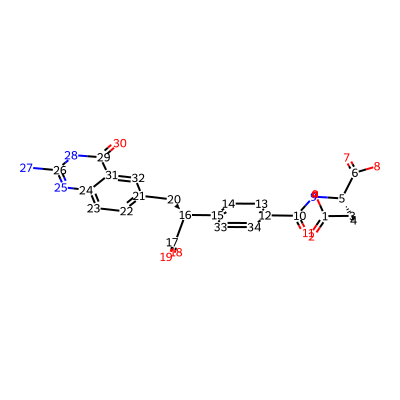

In [5]:
from rdkit.Chem import Draw
from rdkit.Chem.Draw import rdMolDraw2D

drawer = rdMolDraw2D.MolDraw2DSVG(400, 400)  # Specify the size of the image

# Drawing options
opts = drawer.drawOptions()
for i in range(ligand_mol.GetNumAtoms()):
    opts.atomLabels[i] = str(i)
drawer.DrawMolecule(ligand_mol)
drawer.FinishDrawing()
svg = drawer.GetDrawingText()  # Get the SVG text

# Display the SVG in a Jupyter notebook
from IPython.display import SVG
SVG(svg.replace('svg:', ''))

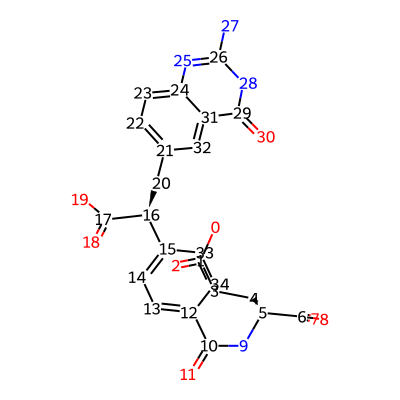

In [6]:
drawer = rdMolDraw2D.MolDraw2DSVG(400, 400)
opts = drawer.drawOptions()
for i in range(docked_mol.GetNumAtoms()):
    opts.atomLabels[i] = str(i)
drawer.DrawMolecule(docked_mol)
drawer.FinishDrawing()
svg = drawer.GetDrawingText()  # Get the SVG text

from IPython.display import SVG
SVG(svg.replace('svg:', ''))

In [7]:
from rdkit.Chem import rdMolAlign
rdMolAlign.AlignMol(ligand_mol, docked_mol)

2.6024819472271212